[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/AM/blob/main/03_naive_bayes.ipynb)


# Aula: Naive Bayes

Nesta aula, combinaremos:

- **intuição probabilística**;
- **implementação prática com `scikit-learn`**;
- **comparações entre diferentes versões do método**.



## Objetivos de aprendizagem

Ao final deste notebook, espera-se que você seja capaz de:

1. interpretar a ideia de classificação probabilística;
2. entender o papel do **Teorema de Bayes**;
3. compreender a hipótese de independência condicional do Naive Bayes;
4. treinar e avaliar modelos com a biblioteca `scikit-learn`;
5. implementar partes importantes do fluxo de modelagem;
6. comparar variantes como:
   - `GaussianNB`
   - `MultinomialNB`
   - `BernoulliNB`

---



## Ideia central

Em classificação, queremos prever o rótulo $y^{(i)}$ de um novo exemplo $x^{(i)}$.

Uma regra natural é escolher a classe mais provável dado o vetor de atributos observado:


$\hat{y} = \arg\max_{c \in \mathcal{Y}} P(Y=c \mid X=x)$

Esse critério é chamado de **MAP** (*Maximum A Posteriori*).

Pelo Teorema de Bayes:


$P(Y=c \mid X=x) = \frac{P(X=x \mid Y=c)\,P(Y=c)}{P(X=x)}$

Como $P(X=x)$ é igual para todas as classes durante a comparação, obtemos:

$\hat{y} = \arg\max_{c \in \mathcal{Y}} P(X=x \mid Y=c)\,P(Y=c)$


Assim, para classificar, precisamos estimar:

- a probabilidade **a priori** da classe: $P(Y=c)$;
- a probabilidade de observar os atributos dado a classe: $P(X=x \mid Y=c)$.


## A hipótese "naive"

Se $\vec{x}=(x_1,\dots,x_p)$, estimar diretamente $P(X=\vec{x} \mid Y=c)$ pode ser muito difícil, especialmente quando há muitos atributos.

O Naive Bayes faz a hipótese de que os atributos são **independentes condicionalmente à classe**:

$$
P(X_1=x_1,\dots,X_p=x_p \mid Y=c) = \prod_{j=1}^{p} P(X_j = x_j \mid Y=c)
$$

Então a regra de decisão fica:

$$
\hat{y} = \arg\max_{c \in \mathcal{Y}} P(Y=c)\prod_{j=1}^{p} P(X_j=x_j \mid Y=c)
$$

Essa hipótese geralmente não é exatamente verdadeira, mas o método costuma funcionar muito bem na prática.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#pd.set_option("display.max_columns", None)


## Primeiro exemplo: Iris

Vamos começar com o conjunto de dados **Iris**, que possui:

- 150 observações;
- 4 atributos numéricos contínuos;
- 3 classes.

Como os atributos são contínuos, a variante mais natural é o **Gaussian Naive Bayes**.


In [2]:
from sklearn.datasets import load_iris, load_wine, load_digits

In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="classe")

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
y.value_counts().sort_index()

,count
classe,
0,50
1,50
2,50



## Separação em treino e teste


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, Binarizer

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamanho de treino:", X_train.shape)
print("Tamanho de teste :", X_test.shape)

Tamanho de treino: (112, 4)
Tamanho de teste : (38, 4)


## Treinando o Gaussian Naive Bayes

No `scikit-learn`, o fluxo básico é:

1. criar o modelo;
2. ajustar com `fit`;
3. obter previsões com `predict`;
4. avaliar o desempenho.


In [7]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)



In [21]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [22]:
df_comparison = pd.DataFrame({
    'Índice Original': y_test.index.values,
    'Rótulos verdadeiros': y_test.values,
    'Rótulos previstos': y_pred
})
df_comparison

,Índice Original,Rótulos verdadeiros,Rótulos previstos
0,42,0,0
1,56,1,1
2,99,1,1
3,53,1,1
4,38,0,0
5,85,1,1
6,134,2,1
7,141,2,2
8,107,2,2
9,132,2,2


In [23]:
print("Acurácia:", round(accuracy_score(y_test, y_pred), 4))

Acurácia: 0.9211


In [24]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38




### Como interpretar esse relatório?

- **precision**: entre os exemplos previstos como pertencentes a uma classe, qual proporção realmente pertence a ela;
- **recall**: entre os exemplos que realmente pertencem a uma classe, qual proporção foi corretamente identificada;
- **f1-score**: média harmônica entre precision e recall;
- **support**: quantidade de exemplos reais de cada classe no conjunto de teste.

A **accuracy** é a proporção total de acertos.

Como o conjunto Iris é relativamente equilibrado, as médias `macro avg` e `weighted avg` tendem a ser próximas.


## Matriz de confusão

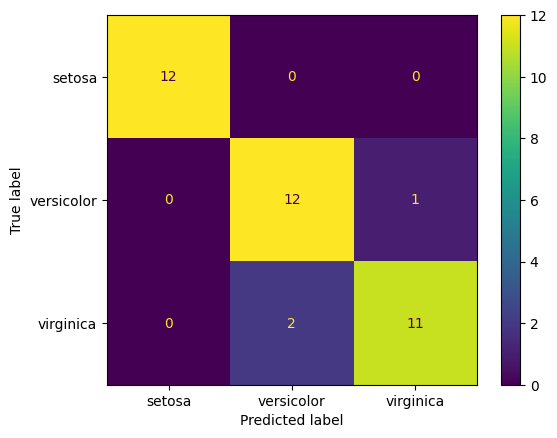

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.show()


A matriz de confusão permite observar **quais classes estão sendo confundidas entre si**.

Nos problemas multiclasses, ela é uma ferramenta importante porque a acurácia sozinha não mostra *onde* o modelo está errando.


## O que o Gaussian Naive Bayes assume?

No caso gaussiano, para cada classe $c$ e atributo $X_j$, supõe-se que:

$X_j \mid Y=c \sim \mathcal{N}(\mu_{jc}, \sigma^2_{jc})$

Ou seja, cada atributo contínuo é modelado por uma distribuição normal dentro de cada classe.

Logo, o algoritmo precisa estimar:

- as probabilidades a priori $P(Y=c)$;
- a média $\mu_{jc}$ de cada atributo em cada classe;
- a variância $\sigma^2_{jc}$ de cada atributo em cada classe.



## Inspecionando os parâmetros aprendidos


In [26]:
priors = pd.Series(gnb.class_prior_, index=iris.target_names, name="prior")
priors

,prior
setosa,0.339286
versicolor,0.330357
virginica,0.330357


In [27]:
medias = pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names)
medias

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.994737,3.450000,1.481579,0.247368
versicolor,5.997297,2.743243,4.264865,1.310811
virginica,6.664865,2.994595,5.608108,2.048649


In [ ]:
variancias = pd.DataFrame(gnb.var_, columns=iris.feature_names, index=iris.target_names)
variancias


Essas tabelas mostram exatamente o que o modelo estimou a partir dos dados de treinamento.

Em outras palavras, o `GaussianNB` constrói um modelo probabilístico simples para cada classe.



# Exercícios práticos



## Exercício 1 — Treino e avaliação em outro conjunto de dados

Repita o fluxo abaixo para o dataset **Wine**:

1. carregue o dataset `load_wine()`;
2. faça a separação treino/teste com `test_size=0.25`, `random_state=42` e `stratify=y`;
3. treine um `GaussianNB`;
4. calcule a acurácia;
5. exiba a matriz de confusão.

**Objetivo:** praticar o uso da biblioteca em outro problema de classificação multiclasses.


In [ ]:
# EXERCÍCIO 1
# Escreva sua solução nesta célula.

# Dica:
# from sklearn.datasets import load_wine



## Exercício 2 — Função de avaliação

Implemente uma função chamada `avaliar_modelo_nb` que receba:

- um modelo do `scikit-learn`;
- `X_train`, `X_test`, `y_train`, `y_test`.

A função deve:

1. ajustar o modelo;
2. prever os rótulos do conjunto de teste;
3. retornar um dicionário com:
   - `"accuracy"`
   - `"y_pred"`

Depois, use essa função para avaliar um `GaussianNB` no dataset Iris.

**Objetivo:** treinar encapsulamento de código e fluxo de modelagem.


In [ ]:
# EXERCÍCIO 2
# Implemente a função abaixo.

def avaliar_modelo_nb(modelo, X_train, X_test, y_train, y_test):
    pass



## Exercício 3 — Comparando train/test split diferentes

Usando o dataset Iris, compare o desempenho do `GaussianNB` para os seguintes valores de `test_size`:

- 0.20
- 0.25
- 0.30
- 0.40

Armazene os resultados em um `DataFrame` com as colunas:

- `test_size`
- `accuracy`

**Objetivo:** perceber que a avaliação depende da divisão dos dados.


In [ ]:
# EXERCÍCIO 3
# Monte um loop e gere um DataFrame com os resultados.



## Exercício 4 — Probabilidades previstas

Treine um `GaussianNB` no Iris e utilize o método:

```python
predict_proba(X_test)
```

Depois:

1. transforme a saída em um `DataFrame`;
2. nomeie as colunas com os nomes das espécies;
3. mostre as 10 primeiras linhas.

**Objetivo:** interpretar o modelo de forma probabilística, e não apenas pelas classes finais.


In [ ]:
# EXERCÍCIO 4
# Use predict_proba e organize a saída em um DataFrame.



## 11. Entendendo `predict_proba`

Vamos ver como o modelo retorna probabilidades a posteriori estimadas.


In [29]:
probs = gnb.predict_proba(X_test)
df_probs = pd.DataFrame(probs, columns=iris.target_names)
df_probs.head(10)

,setosa,versicolor,virginica
0,1.000000e+00,3.058990e-20,5.939279e-27
1,1.758500e-135,6.390746e-01,3.609254e-01
2,8.776343e-88,9.999361e-01,6.387859e-05
3,4.262845e-83,9.999839e-01,1.614444e-05
4,1.000000e+00,1.240216e-19,1.232017e-26
5,1.429689e-121,8.435534e-01,1.564466e-01
6,1.245488e-189,6.146951e-01,3.853049e-01
7,2.100669e-210,6.427607e-08,9.999999e-01
8,3.719689e-279,5.172329e-07,9.999995e-01
9,3.499172e-237,3.225788e-07,9.999997e-01



Cada linha representa um exemplo do conjunto de teste, e cada coluna indica a probabilidade estimada de pertencimento a uma classe.

A previsão final (`predict`) corresponde à classe com maior valor em cada linha.



## 12. Comparando `predict` e `predict_proba`


In [30]:
comparacao = X_test.copy().reset_index(drop=True)
comparacao["classe_real"] = y_test.reset_index(drop=True).map(dict(enumerate(iris.target_names)))
comparacao["classe_prevista"] = pd.Series(y_pred).map(dict(enumerate(iris.target_names)))

for nome in iris.target_names:
    comparacao[f"prob_{nome}"] = df_probs[nome].values

comparacao.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),classe_real,classe_prevista,prob_setosa,prob_versicolor,prob_virginica
0,4.4,3.2,1.3,0.2,setosa,setosa,1.000000e+00,3.058990e-20,5.939279e-27
1,6.3,3.3,4.7,1.6,versicolor,versicolor,1.758500e-135,6.390746e-01,3.609254e-01
2,5.7,2.8,4.1,1.3,versicolor,versicolor,8.776343e-88,9.999361e-01,6.387859e-05
3,5.5,2.3,4.0,1.3,versicolor,versicolor,4.262845e-83,9.999839e-01,1.614444e-05
4,4.4,3.0,1.3,0.2,setosa,setosa,1.000000e+00,1.240216e-19,1.232017e-26
5,6.0,3.4,4.5,1.6,versicolor,versicolor,1.429689e-121,8.435534e-01,1.564466e-01
6,6.1,2.6,5.6,1.4,virginica,versicolor,1.245488e-189,6.146951e-01,3.853049e-01
7,6.9,3.1,5.1,2.3,virginica,virginica,2.100669e-210,6.427607e-08,9.999999e-01
8,7.3,2.9,6.3,1.8,virginica,virginica,3.719689e-279,5.172329e-07,9.999995e-01
9,6.4,2.8,5.6,2.2,virginica,virginica,3.499172e-237,3.225788e-07,9.999997e-01



## Exercício 5 — Casos mais incertos

Usando a tabela acima ou o resultado de `predict_proba`, identifique os **5 exemplos mais incertos** do conjunto de teste.

Sugestão: uma forma de medir incerteza é usar a maior probabilidade prevista em cada linha. Quanto menor esse valor máximo, maior a incerteza do modelo.

Crie uma tabela com:

- índice do exemplo;
- classe real;
- classe prevista;
- maior probabilidade prevista.

**Objetivo:** praticar manipulação de probabilidades e interpretação do classificador.


In [ ]:
# EXERCÍCIO 5
# Gere a tabela solicitada.
